In [4]:
import math
import asyncio.taskgroups
import asyncio.taskgroups
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from fuzzywuzzy import fuzz

C:\Users\alsom\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [5]:
AAPL = pd.read_csv("AAPL_combined.csv")
AMZN = pd.read_csv("AMZN_combined.csv")
FB = pd.read_csv("FB_combined.csv")
NVDA = pd.read_csv("NVDA_combined.csv")
TSLA = pd.read_csv("TSLA_combined.csv")

AAPL.head(20)
AMZN.head(20)
FB.head(20)
NVDA.head(20)
TSLA.head(20)

C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\3528224224.py:1: DtypeWarning: Columns (7,15) have mixed types. Specify dtype option on import or set low_memory=False.
  AAPL = pd.read_csv("AAPL_combined.csv")
C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\3528224224.py:2: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  AMZN = pd.read_csv("AMZN_combined.csv")
C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\3528224224.py:3: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  FB = pd.read_csv("FB_combined.csv")
C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\3528224224.py:4: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  NVDA = pd.read_csv("NVDA_combined.csv")
C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\3528224224.py:5: DtypeWarning: Columns (13,15) have mixed types. Specify dtype option on import or set low_me

,Unnamed: 0,id,body,created_at,user,source,symbols,mentioned_users,entities,links,likes,conversation,reshare_message,owned_symbols,reshares,structurable
0,14974,188017660,$TSLA 🤙,2019-12-24 20:45:19+00:00,"{'id': 561032, 'username': 'RichOnABoatInMaine...","{'id': 1149, 'title': 'StockTwits for iOS', 'u...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],{'sentiment': {'basic': 'Bullish'}},NaN,NaN,NaN,NaN,"['4', '1', '3', '0', '3', '0', '0', '0', '0', ...",NaN,NaN
1,14973,188017676,$TSLA it so painful holding puts over Xmas but...,2019-12-24 20:45:49+00:00,"{'id': 2025803, 'username': 'NeverGiveUpZ', 'n...","{'id': 1149, 'title': 'StockTwits for iOS', 'u...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],{'sentiment': {'basic': 'Bearish'}},NaN,"{'total': 2, 'user_ids': [788054, 1226835]}","{'parent_message_id': 188017676, 'in_reply_to_...",NaN,"['27', '19', '8', '0', '8', '22', '0', '2', '0...",NaN,NaN
2,14972,188017707,$SHAK sorry Morgan Stanley your price targets ...,2019-12-24 20:46:39+00:00,"{'id': 1466616, 'username': 'ironwill21', 'nam...","{'id': 1149, 'title': 'StockTwits for iOS', 'u...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],{'chart': {'thumb': 'https://charts.stocktwits...,NaN,"{'total': 7, 'user_ids': [202337, 2728220, 212...","{'parent_message_id': 188017707, 'in_reply_to_...",NaN,"['22', '18', '4', '0', '4', '26', '0', '0', '0...",NaN,NaN
3,14971,188017940,$TSLA oh boy! Going to ROCKET Thursday! 450 by...,2019-12-24 20:49:34+00:00,"{'id': 1550684, 'username': 'CheapAlmonds', 'n...","{'id': 1149, 'title': 'StockTwits for iOS', 'u...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],{'sentiment': {'basic': 'Bullish'}},NaN,"{'total': 4, 'user_ids': [572878, 1270136, 102...","{'parent_message_id': 188017940, 'in_reply_to_...",NaN,"['7', '6', '1', '0', '1', '10', '1', '2', '0',...",NaN,NaN
4,14970,188018067,$SPY $TSLA \n\nWhy is Tesla at 425?,2019-12-24 20:52:52+00:00,"{'id': 2199581, 'username': 'JAGXFriend', 'nam...","{'id': 2269, 'title': 'StockTwits Web', 'url':...","[{'id': 7271, 'symbol': 'SPY', 'title': 'SPDR ...",[],{'sentiment': None},NaN,NaN,"{'parent_message_id': 188018067, 'in_reply_to_...",NaN,"['4', '3', '1', '0', '1', '2', '0', '1', '1', ...",NaN,NaN
5,14969,188018095,$TSLA This is why TESLA will always STAND OUT ...,2019-12-24 20:53:33+00:00,"{'id': 553222, 'username': 'ByGraceThruFaith',...","{'id': 2269, 'title': 'StockTwits Web', 'url':...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],{'chart': {'thumb': 'https://charts.stocktwits...,NaN,"{'total': 5, 'user_ids': [2728220, 1906472, 29...",NaN,NaN,"['12', '11', '0', '1', '1', '25', '0', '0', '0...",NaN,NaN
6,14968,188018197,$TSLA possibility that it&#39;s gonna run up i...,2019-12-24 20:55:52+00:00,"{'id': 260529, 'username': 'pewpewpewpewpew', ...","{'id': 2269, 'title': 'StockTwits Web', 'url':...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],{'sentiment': {'basic': 'Bullish'}},NaN,NaN,NaN,NaN,"['2', '2', '0', '0', '0', '1', '0', '0', '0', ...",NaN,NaN
7,14967,188018202,$TSLA good look at new traffic visualizations...,2019-12-24 20:55:58+00:00,"{'id': 584870, 'username': 'holleryall', 'name...","{'id': 2269, 'title': 'StockTwits Web', 'url':...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],{'sentiment': {'basic': 'Bullish'}},[{'title': 'Tesla Software 2019.40.50 -- First...,"{'total': 2, 'user_ids': [572878, 707393]}",NaN,NaN,"['19', '5', '14', '0', '14', '1', '1', '1', '1...",NaN,NaN
8,14966,188018268,$TSLA ride the open blue skies. Last time TESL...,2019-12-24 20:57:17+00:00,"{'id': 767238, 'username': 'Thankfulness', 'na...","{'id': 1149, 'title': 'StockTwits for iOS', 'u...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],{'sentiment': {'basic': 'Bullish'}},NaN,"{'total': 4, 'user_ids': [572878, 402859, 9944...",NaN,NaN,"['4', '1', '2', '1', '3', '2', '0', '0', '0', ...",NaN,NaN
9,14965,188018345,$TSLA I just shorted this. Have not felt mor...,2019-12-24 20:59:00+00:00,"{

In [6]:
import ast

def clean_entities_sentiment(val):
    if pd.isna(val):
        return 0
    try:
        # Parse the string as a dictionary
        d = ast.literal_eval(val)
        
        # Check if 'sentiment' key exists
        if 'sentiment' in d:
            sentiment_data = d['sentiment']
            
            # If sentiment is None, return 0
            if sentiment_data is None:
                return 0
            
            # If sentiment is a dictionary, look for 'basic' key
            if isinstance(sentiment_data, dict):
                basic_sentiment = sentiment_data.get('basic')
                if basic_sentiment == 'Bullish':
                    return 1
                elif basic_sentiment == 'Bearish':
                    return -1
        
        # If we reach here, it's Neutral/None or unknown structure
        return 0
        
    except (ValueError, SyntaxError) as e:
        # Handle cases where the string isn't valid python literal
        return 0

# Apply to all dataframes
datasets = [AAPL, AMZN, FB, NVDA, TSLA]
dataset_names = ["AAPL", "AMZN", "FB", "NVDA", "TSLA"]

for df, name in zip(datasets, dataset_names):
    print(f"Processing {name}...")
    df['entities'] = df['entities'].apply(clean_entities_sentiment)
    print(f"Unique values in {name}['entities'] after cleaning: {df['entities'].unique()}")
    print("-" * 20)

# Verify the result on AAPL
print(AAPL[['entities']].head())

Processing AAPL...
Unique values in AAPL['entities'] after cleaning: [ 0  1 -1]
--------------------
Processing AMZN...
Unique values in AMZN['entities'] after cleaning: [ 0  1 -1]
--------------------
Processing FB...
Unique values in FB['entities'] after cleaning: [ 0  1 -1]
--------------------
Processing NVDA...
Unique values in NVDA['entities'] after cleaning: [ 0  1 -1]
--------------------
Processing TSLA...
Unique values in TSLA['entities'] after cleaning: [ 1 -1  0]
--------------------
   entities
0         0
1         0
2         1
3         1
4         0


In [7]:
AAPL.head(20)
AMZN.head(20)
FB.head(20)
NVDA.head(20)
TSLA.head(20)

,Unnamed: 0,id,body,created_at,user,source,symbols,mentioned_users,entities,links,likes,conversation,reshare_message,owned_symbols,reshares,structurable
0,14974,188017660,$TSLA 🤙,2019-12-24 20:45:19+00:00,"{'id': 561032, 'username': 'RichOnABoatInMaine...","{'id': 1149, 'title': 'StockTwits for iOS', 'u...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],1,NaN,NaN,NaN,NaN,"['4', '1', '3', '0', '3', '0', '0', '0', '0', ...",NaN,NaN
1,14973,188017676,$TSLA it so painful holding puts over Xmas but...,2019-12-24 20:45:49+00:00,"{'id': 2025803, 'username': 'NeverGiveUpZ', 'n...","{'id': 1149, 'title': 'StockTwits for iOS', 'u...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],-1,NaN,"{'total': 2, 'user_ids': [788054, 1226835]}","{'parent_message_id': 188017676, 'in_reply_to_...",NaN,"['27', '19', '8', '0', '8', '22', '0', '2', '0...",NaN,NaN
2,14972,188017707,$SHAK sorry Morgan Stanley your price targets ...,2019-12-24 20:46:39+00:00,"{'id': 1466616, 'username': 'ironwill21', 'nam...","{'id': 1149, 'title': 'StockTwits for iOS', 'u...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],1,NaN,"{'total': 7, 'user_ids': [202337, 2728220, 212...","{'parent_message_id': 188017707, 'in_reply_to_...",NaN,"['22', '18', '4', '0', '4', '26', '0', '0', '0...",NaN,NaN
3,14971,188017940,$TSLA oh boy! Going to ROCKET Thursday! 450 by...,2019-12-24 20:49:34+00:00,"{'id': 1550684, 'username': 'CheapAlmonds', 'n...","{'id': 1149, 'title': 'StockTwits for iOS', 'u...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],1,NaN,"{'total': 4, 'user_ids': [572878, 1270136, 102...","{'parent_message_id': 188017940, 'in_reply_to_...",NaN,"['7', '6', '1', '0', '1', '10', '1', '2', '0',...",NaN,NaN
4,14970,188018067,$SPY $TSLA \n\nWhy is Tesla at 425?,2019-12-24 20:52:52+00:00,"{'id': 2199581, 'username': 'JAGXFriend', 'nam...","{'id': 2269, 'title': 'StockTwits Web', 'url':...","[{'id': 7271, 'symbol': 'SPY', 'title': 'SPDR ...",[],0,NaN,NaN,"{'parent_message_id': 188018067, 'in_reply_to_...",NaN,"['4', '3', '1', '0', '1', '2', '0', '1', '1', ...",NaN,NaN
5,14969,188018095,$TSLA This is why TESLA will always STAND OUT ...,2019-12-24 20:53:33+00:00,"{'id': 553222, 'username': 'ByGraceThruFaith',...","{'id': 2269, 'title': 'StockTwits Web', 'url':...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],1,NaN,"{'total': 5, 'user_ids': [2728220, 1906472, 29...",NaN,NaN,"['12', '11', '0', '1', '1', '25', '0', '0', '0...",NaN,NaN
6,14968,188018197,$TSLA possibility that it&#39;s gonna run up i...,2019-12-24 20:55:52+00:00,"{'id': 260529, 'username': 'pewpewpewpewpew', ...","{'id': 2269, 'title': 'StockTwits Web', 'url':...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],1,NaN,NaN,NaN,NaN,"['2', '2', '0', '0', '0', '1', '0', '0', '0', ...",NaN,NaN
7,14967,188018202,$TSLA good look at new traffic visualizations...,2019-12-24 20:55:58+00:00,"{'id': 584870, 'username': 'holleryall', 'name...","{'id': 2269, 'title': 'StockTwits Web', 'url':...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],1,[{'title': 'Tesla Software 2019.40.50 -- First...,"{'total': 2, 'user_ids': [572878, 707393]}",NaN,NaN,"['19', '5', '14', '0', '14', '1', '1', '1', '1...",NaN,NaN
8,14966,188018268,$TSLA ride the open blue skies. Last time TESL...,2019-12-24 20:57:17+00:00,"{'id': 767238, 'username': 'Thankfulness', 'na...","{'id': 1149, 'title': 'StockTwits for iOS', 'u...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],1,NaN,"{'total': 4, 'user_ids': [572878, 402859, 9944...",NaN,NaN,"['4', '1', '2', '1', '3', '2', '0', '0', '0', ...",NaN,NaN
9,14965,188018345,$TSLA I just shorted this. Have not felt mor...,2019-12-24 20:59:00+00:00,"{'id': 493222, 'username': 'jeff131415', 'name...","{'id': 1149, 'title': 'StockTwits for iOS', 'u...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],0,NaN,"{'total': 9, 'user_ids': [1117296, 2898340, 92...","{'parent_message_id': 188018345, 'in_reply_to_...",NaN,"['2', '2', '0', '0', '0', '0', '0', '1', '0',

In [8]:
# Text cleaning utilities: lowercase, remove URLs/HTML/emoji/handles/hashtags, normalize unicode, expand contractions
import re
import html
import unicodedata
import pandas as pd

# small contractions map (add more as needed)
_CONTRACTIONS = {
    "can't": "cannot",
    "won't": "will not",
    "i'm": "i am",
    "it's": "it is",
    "that's": "that is",
    "you're": "you are",
    "we're": "we are",
    "they're": "they are",
    "she's": "she is",
    "he's": "he is",
    "ain't": "is not",
    "let's": "let us",
    "'ve": " have",
    "'re": " are",
    "'ll": " will",
    "'d": " would",
    "n't": " not"
}

_CONTRACTIONS_RE = re.compile('|'.join(re.escape(k) for k in _CONTRACTIONS.keys()), flags=re.IGNORECASE)

def _expand_contractions(text: str) -> str:
    def _repl(m):
        key = m.group(0).lower()
        return _CONTRACTIONS.get(key, key)
    return _CONTRACTIONS_RE.sub(_repl, text)

# basic emoji range pattern (covers common emoji ranges)
_EMOJI_RE = re.compile("[\U0001F300-\U0001F6FF\U0001F900-\U0001F9FF\U0001F1E0-\U0001F1FF]+", flags=re.UNICODE)

def clean_text(text, *, remove_urls=True, remove_html=True, remove_emoji=True, remove_handles=True, remove_hashtags=True, expand_contractions=True) -> str:
    if pd.isna(text):
        return ""
    s = str(text)
    # normalize unicode and unescape HTML entities
    s = unicodedata.normalize('NFKC', s)
    s = html.unescape(s)
    # lower for consistent processing
    s = s.lower()
    # expand contractions (before removing punctuation)
    if expand_contractions:
        s = _expand_contractions(s)
    # remove urls
    if remove_urls:
        s = re.sub(r'https?://\S+|www\.\S+', '', s)
    # remove html tags
    if remove_html:
        s = re.sub(r'<[^>]+>', '', s)
    # handle user handles
    if remove_handles:
        s = re.sub(r'@\w+', '', s)
    # hashtags: either remove entirely or keep text without '#'.
    if remove_hashtags:
        s = re.sub(r'#\w+', '', s)
    else:
        s = re.sub(r'#', '', s)
    # remove emoji
    if remove_emoji:
        s = _EMOJI_RE.sub('', s)
    # remove leftover non-printable/control characters
    s = re.sub(r'[\r\t\x0b\x0c]', ' ', s)
    # collapse whitespace
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def clean_series(series: pd.Series, **kwargs) -> pd.Series:
    return series.fillna('').astype(str).map(lambda x: clean_text(x, **kwargs))

# Example usage (uncomment to run):
# AAPL['clean_text'] = clean_series(AAPL['text'])
# print(AAPL['clean_text'].head())

In [9]:
# Clean the 'body' column (social media posts) for all datasets

print("Cleaning 'body' column for all datasets...")
for df, name in zip(datasets, dataset_names):
    print(f"\nProcessing {name}...")
    df['body_clean'] = clean_series(df['body'])
    print(f"Sample cleaned text from {name}:")
    print(f"  Original: {df['body'].iloc[0][:100]}...")
    print(f"  Cleaned:  {df['body_clean'].iloc[0][:100]}...")

print("\nCleaning complete!")


Cleaning 'body' column for all datasets...

Processing AAPL...
Sample cleaned text from AAPL:
  Original: $AAPL UN-stoppable! 🎉🥂...
  Cleaned:  $aapl un-stoppable!...

Processing AMZN...
Sample cleaned text from AMZN:
  Original: $AMZN $FB $GOOG $AAPL 
Sounds like retail investors may capitulate soon judging by the mood of the f...
  Cleaned:  $amzn $fb $goog $aapl sounds like retail investors may capitulate soon judging by the mood of the fa...

Processing FB...
Sample cleaned text from FB:
  Original: $FB $205 call buyers...
  Cleaned:  $fb $205 call buyers...

Processing NVDA...
Sample cleaned text from NVDA:
  Original: $NVDA shorts using a lot of ammo trying to keep it down,not working...
  Cleaned:  $nvda shorts using a lot of ammo trying to keep it down,not working...

Processing TSLA...
Sample cleaned text from TSLA:
  Original: $TSLA 🤙...
  Cleaned:  $tsla...

Cleaning complete!


A body clean column is added at the end


In [10]:
AAPL.head(20)
AMZN.head(20)
FB.head(20)
NVDA.head(20)
TSLA.head(20)

,Unnamed: 0,id,body,created_at,user,source,symbols,mentioned_users,entities,links,likes,conversation,reshare_message,owned_symbols,reshares,structurable,body_clean
0,14974,188017660,$TSLA 🤙,2019-12-24 20:45:19+00:00,"{'id': 561032, 'username': 'RichOnABoatInMaine...","{'id': 1149, 'title': 'StockTwits for iOS', 'u...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],1,NaN,NaN,NaN,NaN,"['4', '1', '3', '0', '3', '0', '0', '0', '0', ...",NaN,NaN,$tsla
1,14973,188017676,$TSLA it so painful holding puts over Xmas but...,2019-12-24 20:45:49+00:00,"{'id': 2025803, 'username': 'NeverGiveUpZ', 'n...","{'id': 1149, 'title': 'StockTwits for iOS', 'u...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],-1,NaN,"{'total': 2, 'user_ids': [788054, 1226835]}","{'parent_message_id': 188017676, 'in_reply_to_...",NaN,"['27', '19', '8', '0', '8', '22', '0', '2', '0...",NaN,NaN,$tsla it so painful holding puts over xmas but...
2,14972,188017707,$SHAK sorry Morgan Stanley your price targets ...,2019-12-24 20:46:39+00:00,"{'id': 1466616, 'username': 'ironwill21', 'nam...","{'id': 1149, 'title': 'StockTwits for iOS', 'u...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],1,NaN,"{'total': 7, 'user_ids': [202337, 2728220, 212...","{'parent_message_id': 188017707, 'in_reply_to_...",NaN,"['22', '18', '4', '0', '4', '26', '0', '0', '0...",NaN,NaN,$shak sorry morgan stanley your price targets ...
3,14971,188017940,$TSLA oh boy! Going to ROCKET Thursday! 450 by...,2019-12-24 20:49:34+00:00,"{'id': 1550684, 'username': 'CheapAlmonds', 'n...","{'id': 1149, 'title': 'StockTwits for iOS', 'u...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],1,NaN,"{'total': 4, 'user_ids': [572878, 1270136, 102...","{'parent_message_id': 188017940, 'in_reply_to_...",NaN,"['7', '6', '1', '0', '1', '10', '1', '2', '0',...",NaN,NaN,$tsla oh boy! going to rocket thursday! 450 by...
4,14970,188018067,$SPY $TSLA \n\nWhy is Tesla at 425?,2019-12-24 20:52:52+00:00,"{'id': 2199581, 'username': 'JAGXFriend', 'nam...","{'id': 2269, 'title': 'StockTwits Web', 'url':...","[{'id': 7271, 'symbol': 'SPY', 'title': 'SPDR ...",[],0,NaN,NaN,"{'parent_message_id': 188018067, 'in_reply_to_...",NaN,"['4', '3', '1', '0', '1', '2', '0', '1', '1', ...",NaN,NaN,$spy $tsla why is tesla at 425?
5,14969,188018095,$TSLA This is why TESLA will always STAND OUT ...,2019-12-24 20:53:33+00:00,"{'id': 553222, 'username': 'ByGraceThruFaith',...","{'id': 2269, 'title': 'StockTwits Web', 'url':...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],1,NaN,"{'total': 5, 'user_ids': [2728220, 1906472, 29...",NaN,NaN,"['12', '11', '0', '1', '1', '25', '0', '0', '0...",NaN,NaN,$tsla this is why tesla will always stand out ...
6,14968,188018197,$TSLA possibility that it&#39;s gonna run up i...,2019-12-24 20:55:52+00:00,"{'id': 260529, 'username': 'pewpewpewpewpew', ...","{'id': 2269, 'title': 'StockTwits Web', 'url':...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],1,NaN,NaN,NaN,NaN,"['2', '2', '0', '0', '0', '1', '0', '0', '0', ...",NaN,NaN,$tsla possibility that it is gonna run up into...
7,14967,188018202,$TSLA good look at new traffic visualizations...,2019-12-24 20:55:58+00:00,"{'id': 584870, 'username': 'holleryall', 'name...","{'id': 2269, 'title': 'StockTwits Web', 'url':...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],1,[{'title': 'Tesla Software 2019.40.50 -- First...,"{'total': 2, 'user_ids': [572878, 707393]}",NaN,NaN,"['19', '5', '14', '0', '14', '1', '1', '1', '1...",NaN,NaN,$tsla good look at new traffic visualizations.
8,14966,188018268,$TSLA ride the open blue skies. Last time TESL...,2019-12-24 20:57:17+00:00,"{'id': 767238, 'username': 'Thankfulness', 'na...","{'id': 1149, 'title': 'StockTwits for iOS', 'u...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],1,NaN,"{'total': 4, 'user_ids': [572878, 402859, 9944...",NaN,NaN,"['4', '1', '2', '1', '3', '2', '0', '0', '0', ...",NaN,NaN,$tsla ride the open blue skies. last time tesl...
9,14965,1880183

Remove


Check for duplicate values


In [11]:
# Duplicate Detection
from collections import Counter

print("=" * 60)
print("DUPLICATE DETECTION")
print("=" * 60)

for df, name in zip(datasets, dataset_names):
    print(f"\n{name}:")
    print(f"  Total rows: {len(df)}")
    
    # Exact duplicates based on 'body_clean'
    exact_dups = df.duplicated(subset=['body_clean'], keep=False).sum()
    print(f"  Exact duplicate rows (body_clean): {exact_dups}")
    
    # Exact duplicates based on 'body' (original)
    exact_dups_orig = df.duplicated(subset=['body'], keep=False).sum()
    print(f"  Exact duplicate rows (original body): {exact_dups_orig}")
    
    # Check for duplicate user-content pairs (same user posting same content)
    user_content_dups = df.duplicated(subset=['user', 'body_clean'], keep=False).sum()
    print(f"  User-content duplicate rows: {user_content_dups}")
    
    # Remove exact duplicates (keep first occurrence)
    df_deduped = df.drop_duplicates(subset=['body_clean'], keep='first')
    duplicates_removed = len(df) - len(df_deduped)
    print(f"  Rows after removing exact duplicates: {len(df_deduped)} - removed {duplicates_removed}")
    
    # Show most repeated content
    if exact_dups > 0:
        top_repeats = df[df.duplicated(subset=['body_clean'], keep=False)]['body_clean'].value_counts().head(3)
        print(f"  Most repeated posts:")
        for idx, (text, count) in enumerate(top_repeats.items(), 1):
            print(f"    {idx}. Posted {count} times: {text[:75]}...")

# Optional: Apply deduplication to all datasets
print("\n" + "=" * 60)
apply_dedup = True  # Set to True to remove duplicates
if apply_dedup:
    print("Removing exact duplicates from all datasets...")
    for i, (df, name) in enumerate(zip(datasets, dataset_names)):
        original_len = len(df)
        datasets[i] = df.drop_duplicates(subset=['body_clean'], keep='first')
        print(f"  {name}: {original_len} -> {len(datasets[i])} rows")
    print("Deduplication complete!")
else:
    print("Deduplication NOT applied. Set apply_dedup=True to remove duplicates.")

DUPLICATE DETECTION

AAPL:
  Total rows: 914962
  Exact duplicate rows (body_clean): 100685
  Exact duplicate rows (original body): 71122
  User-content duplicate rows: 55064
  Rows after removing exact duplicates: 830258 - removed 84704
  Most repeated posts:
    1. Posted 27474 times: $aapl...
    2. Posted 647 times: your daily news digest for apple inc $aapl...
    3. Posted 436 times: $spy $aapl...

AMZN:
  Total rows: 539803
  Exact duplicate rows (body_clean): 56268
  Exact duplicate rows (original body): 40205
  User-content duplicate rows: 31735
  Rows after removing exact duplicates: 493506 - removed 46297
  Most repeated posts:
    1. Posted 11367 times: $amzn...
    2. Posted 653 times: your daily news digest for amazon.com $amzn...
    3. Posted 298 times: $amzn lol...

FB:
  Total rows: 359908
  Exact duplicate rows (body_clean): 45013
  Exact duplicate rows (original body): 32599
  User-content duplicate rows: 26417
  Rows after removing exact duplicates: 322725 - remove

Remove Stop Words


In [12]:
# Remove Stop Words
from nltk.corpus import stopwords
import nltk

# Download stopwords (run once)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# Get English stop words
stop_words = set(stopwords.words('english'))

# Add custom financial stop words that may not be useful
custom_stop_words = {'stock', 'price', 'market', 'will', 'would', 'could', 'said', 'say'}
stop_words.update(custom_stop_words)

def remove_stopwords(text):
    """Remove stop words from text"""
    if pd.isna(text) or text == "":
        return ""
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered_words)

print("=" * 60)
print("REMOVING STOP WORDS")
print("=" * 60)

for df, name in zip(datasets, dataset_names):
    print(f"\n{name}:")
    df['body_no_stopwords'] = df['body_clean'].apply(remove_stopwords)
    
    # Show comparison
    sample_idx = 0
    print(f"  Sample before: {df['body_clean'].iloc[sample_idx][:100]}")
    print(f"  Sample after:  {df['body_no_stopwords'].iloc[sample_idx][:100]}")
    
    # Count average words removed
    before_count = df['body_clean'].apply(lambda x: len(str(x).split())).mean()
    after_count = df['body_no_stopwords'].apply(lambda x: len(str(x).split())).mean()
    print(f"  Avg words before: {before_count:.1f} → after: {after_count:.1f} ({100*(before_count-after_count)/before_count:.1f}% removed)")

print("\nStop word removal complete!")

REMOVING STOP WORDS

AAPL:


C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\897213736.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['body_no_stopwords'] = df['body_clean'].apply(remove_stopwords)


  Sample before: $aapl un-stoppable!
  Sample after:  $aapl un-stoppable!
  Avg words before: 18.6 → after: 12.0 (35.5% removed)

AMZN:


C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\897213736.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['body_no_stopwords'] = df['body_clean'].apply(remove_stopwords)


  Sample before: $amzn $fb $goog $aapl sounds like retail investors may capitulate soon judging by the mood of the fa
  Sample after:  $amzn $fb $goog $aapl sounds like retail investors may capitulate soon judging mood faang threads.. 
  Avg words before: 19.5 → after: 12.6 (35.4% removed)

FB:


...

  Sample before: $fb $205 call buyers
  Sample after:  $fb $205 call buyers
  Avg words before: 18.6 → after: 12.1 (34.7% removed)

NVDA:


C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\897213736.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['body_no_stopwords'] = df['body_clean'].apply(remove_stopwords)


  Sample before: $nvda shorts using a lot of ammo trying to keep it down,not working
  Sample after:  $nvda shorts using lot ammo trying keep down,not working
  Avg words before: 15.3 → after: 10.1 (34.2% removed)

TSLA:


C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\897213736.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['body_no_stopwords'] = df['body_clean'].apply(remove_stopwords)


  Sample before: $tsla
  Sample after:  $tsla
  Avg words before: 17.9 → after: 11.3 (37.1% removed)

Stop word removal complete!


In [13]:
AAPL.head(20)
AMZN.head(20)
FB.head(20)
NVDA.head(20)
TSLA.head(20)

,Unnamed: 0,id,body,created_at,user,source,symbols,mentioned_users,entities,links,likes,conversation,reshare_message,owned_symbols,reshares,structurable,body_clean
0,14974,188017660,$TSLA 🤙,2019-12-24 20:45:19+00:00,"{'id': 561032, 'username': 'RichOnABoatInMaine...","{'id': 1149, 'title': 'StockTwits for iOS', 'u...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],1,NaN,NaN,NaN,NaN,"['4', '1', '3', '0', '3', '0', '0', '0', '0', ...",NaN,NaN,$tsla
1,14973,188017676,$TSLA it so painful holding puts over Xmas but...,2019-12-24 20:45:49+00:00,"{'id': 2025803, 'username': 'NeverGiveUpZ', 'n...","{'id': 1149, 'title': 'StockTwits for iOS', 'u...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],-1,NaN,"{'total': 2, 'user_ids': [788054, 1226835]}","{'parent_message_id': 188017676, 'in_reply_to_...",NaN,"['27', '19', '8', '0', '8', '22', '0', '2', '0...",NaN,NaN,$tsla it so painful holding puts over xmas but...
2,14972,188017707,$SHAK sorry Morgan Stanley your price targets ...,2019-12-24 20:46:39+00:00,"{'id': 1466616, 'username': 'ironwill21', 'nam...","{'id': 1149, 'title': 'StockTwits for iOS', 'u...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],1,NaN,"{'total': 7, 'user_ids': [202337, 2728220, 212...","{'parent_message_id': 188017707, 'in_reply_to_...",NaN,"['22', '18', '4', '0', '4', '26', '0', '0', '0...",NaN,NaN,$shak sorry morgan stanley your price targets ...
3,14971,188017940,$TSLA oh boy! Going to ROCKET Thursday! 450 by...,2019-12-24 20:49:34+00:00,"{'id': 1550684, 'username': 'CheapAlmonds', 'n...","{'id': 1149, 'title': 'StockTwits for iOS', 'u...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],1,NaN,"{'total': 4, 'user_ids': [572878, 1270136, 102...","{'parent_message_id': 188017940, 'in_reply_to_...",NaN,"['7', '6', '1', '0', '1', '10', '1', '2', '0',...",NaN,NaN,$tsla oh boy! going to rocket thursday! 450 by...
4,14970,188018067,$SPY $TSLA \n\nWhy is Tesla at 425?,2019-12-24 20:52:52+00:00,"{'id': 2199581, 'username': 'JAGXFriend', 'nam...","{'id': 2269, 'title': 'StockTwits Web', 'url':...","[{'id': 7271, 'symbol': 'SPY', 'title': 'SPDR ...",[],0,NaN,NaN,"{'parent_message_id': 188018067, 'in_reply_to_...",NaN,"['4', '3', '1', '0', '1', '2', '0', '1', '1', ...",NaN,NaN,$spy $tsla why is tesla at 425?
5,14969,188018095,$TSLA This is why TESLA will always STAND OUT ...,2019-12-24 20:53:33+00:00,"{'id': 553222, 'username': 'ByGraceThruFaith',...","{'id': 2269, 'title': 'StockTwits Web', 'url':...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],1,NaN,"{'total': 5, 'user_ids': [2728220, 1906472, 29...",NaN,NaN,"['12', '11', '0', '1', '1', '25', '0', '0', '0...",NaN,NaN,$tsla this is why tesla will always stand out ...
6,14968,188018197,$TSLA possibility that it&#39;s gonna run up i...,2019-12-24 20:55:52+00:00,"{'id': 260529, 'username': 'pewpewpewpewpew', ...","{'id': 2269, 'title': 'StockTwits Web', 'url':...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],1,NaN,NaN,NaN,NaN,"['2', '2', '0', '0', '0', '1', '0', '0', '0', ...",NaN,NaN,$tsla possibility that it is gonna run up into...
7,14967,188018202,$TSLA good look at new traffic visualizations...,2019-12-24 20:55:58+00:00,"{'id': 584870, 'username': 'holleryall', 'name...","{'id': 2269, 'title': 'StockTwits Web', 'url':...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],1,[{'title': 'Tesla Software 2019.40.50 -- First...,"{'total': 2, 'user_ids': [572878, 707393]}",NaN,NaN,"['19', '5', '14', '0', '14', '1', '1', '1', '1...",NaN,NaN,$tsla good look at new traffic visualizations.
8,14966,188018268,$TSLA ride the open blue skies. Last time TESL...,2019-12-24 20:57:17+00:00,"{'id': 767238, 'username': 'Thankfulness', 'na...","{'id': 1149, 'title': 'StockTwits for iOS', 'u...","[{'id': 8660, 'symbol': 'TSLA', 'title': 'Tesl...",[],1,NaN,"{'total': 4, 'user_ids': [572878, 402859, 9944...",NaN,NaN,"['4', '1', '2', '1', '3', '2', '0', '0', '0', ...",NaN,NaN,$tsla ride the open blue skies. last time tesl...
9,14965,1880183

Termoral features


In [14]:
# Temporal Features Engineering
print("=" * 60)
print("TEMPORAL FEATURES EXTRACTION")
print("=" * 60)

# First, identify the timestamp column
timestamp_cols = ['created_at', 'timestamp', 'date', 'published_at', 'post_date']
time_col = None

for df, name in zip(datasets, dataset_names):
    print(f"\n{name} columns: {df.columns.tolist()}")
    # Find which column is the timestamp
    for col in timestamp_cols:
        if col in df.columns:
            time_col = col
            print(f"  Found timestamp column: '{time_col}'")
            break
    if time_col:
        break

if time_col:
    print(f"\nUsing '{time_col}' as timestamp column for all datasets")
    
    for df, name in zip(datasets, dataset_names):
        print(f"\nProcessing {name}...")
        
        # Convert to datetime
        df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
        
        # ===== TIME-OF-DAY FEATURES =====
        df['hour'] = df[time_col].dt.hour
        df['minute'] = df[time_col].dt.minute
        df['time_period'] = pd.cut(df['hour'], 
                                    bins=[0, 6, 12, 18, 24], 
                                    labels=['night', 'morning', 'afternoon', 'evening'],
                                    right=False)
        
        # ===== DATE FEATURES =====
        df['day_of_week'] = df[time_col].dt.dayofweek  # 0=Monday, 6=Sunday
        df['day_name'] = df[time_col].dt.day_name()
        df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
        df['day_of_month'] = df[time_col].dt.day
        df['month'] = df[time_col].dt.month
        df['quarter'] = df[time_col].dt.quarter
        df['week_of_year'] = df[time_col].dt.isocalendar().week
        df['year'] = df[time_col].dt.year
        
        # ===== TREND FEATURES =====
        # Posts per hour (rolling window)
        df['posts_per_hour'] = df.groupby(df[time_col].dt.floor('h')).cumcount() + 1
        
        # Sentiment trend (rolling average using groupby)
        if 'entities' in df.columns:
            # Sort by timestamp first for rolling calculation
            df = df.sort_values(by=time_col).reset_index(drop=True)
            # Calculate rolling mean with a fixed window of 24 rows instead of 24 hours
            df['sentiment_rolling_mean_24'] = df['entities'].rolling(window=24, min_periods=1).mean()
        
        # Time since last post (in minutes)
        df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
        df['time_since_last_post'] = df[time_col].diff().dt.total_seconds() / 60
        df['time_since_last_post'] = df['time_since_last_post'].fillna(0)
        
        # Cumulative posts by user over time
        df['user_post_count'] = df.groupby('user').cumcount() + 1
        
        print(f"  ✓ Temporal features created successfully")
        print(f"  Sample time features:")
        print(f"    Hour range: {df['hour'].min():.0f} to {df['hour'].max():.0f}")
        print(f"    Day of week: {sorted(df['day_of_week'].unique())}")
        print(f"    Weekend posts: {df['is_weekend'].sum()} / {len(df)}")
        print(f"    Avg posts per hour: {df['posts_per_hour'].mean():.2f}")
        print(f"    Max user post count: {df['user_post_count'].max():.0f}")
else:
    print("ERROR: Could not find timestamp column in data!")
    print("Expected one of:", timestamp_cols)


TEMPORAL FEATURES EXTRACTION

AAPL columns: ['Unnamed: 0', 'id', 'body', 'created_at', 'user', 'source', 'symbols', 'owned_symbols', 'mentioned_users', 'entities', 'conversation', 'likes', 'links', 'reshares', 'reshare_message', 'structurable', 'body_clean', 'body_no_stopwords']
  Found timestamp column: 'created_at'

Using 'created_at' as timestamp column for all datasets

Processing AAPL...


C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\3092592989.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\3092592989.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hour'] = df[time_col].dt.hour
C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\3092592989.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,co

  ✓ Temporal features created successfully
  Sample time features:
    Hour range: 0 to 23
    Day of week: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]
    Weekend posts: 59023 / 830258
    Avg posts per hour: 89.12
    Max user post count: 8557

Processing AMZN...


C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\3092592989.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\3092592989.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hour'] = df[time_col].dt.hour
C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\3092592989.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,co

  ✓ Temporal features created successfully
  Sample time features:
    Hour range: 0 to 23
    Day of week: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]
    Weekend posts: 31955 / 493506
    Avg posts per hour: 68.20
    Max user post count: 3342

Processing FB...


...

  ✓ Temporal features created successfully
  Sample time features:
    Hour range: 0 to 23
    Day of week: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]
    Weekend posts: 23085 / 322725
    Avg posts per hour: 97.59
    Max user post count: 1790

Processing NVDA...


C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\3092592989.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\3092592989.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hour'] = df[time_col].dt.hour
C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\3092592989.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,co

  ✓ Temporal features created successfully
  Sample time features:
    Hour range: 0 to 23
    Day of week: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]
    Weekend posts: 25465 / 529740
    Avg posts per hour: 59.45
    Max user post count: 13387

Processing TSLA...


C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\3092592989.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\3092592989.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hour'] = df[time_col].dt.hour
C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\3092592989.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,co

  ✓ Temporal features created successfully
  Sample time features:
    Hour range: 0 to 23
    Day of week: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]
    Weekend posts: 129417 / 1953479
    Avg posts per hour: 183.24
    Max user post count: 5578


In [15]:
# Display temporal features
print("=" * 60)
print("TEMPORAL FEATURES SUMMARY")
print("=" * 60)

for df, name in zip(datasets, dataset_names):
    print(f"\n{name} - Sample of temporal features:")
    temporal_cols = ['hour', 'day_of_week', 'day_name', 'is_weekend', 'month', 
                     'posts_per_hour', 'time_since_last_post', 'user_post_count']
    
    # Show columns that exist
    existing_cols = [col for col in temporal_cols if col in df.columns]
    if existing_cols:
        print(df[existing_cols].head(10))
    
    if 'hour' in df.columns:
        print(f"\n{name} - Temporal features stats:")
        print(f"  Hour distribution:\n{df['hour'].value_counts().sort_index()}")
        if 'day_name' in df.columns:
            print(f"  Posts by day of week:\n{df['day_name'].value_counts()}")


TEMPORAL FEATURES SUMMARY

AAPL - Sample of temporal features:
   hour  day_of_week day_name  is_weekend  month  posts_per_hour
0    21            1  Tuesday           0     12               1
1    21            1  Tuesday           0     12               2
2    21            1  Tuesday           0     12               3
3    21            1  Tuesday           0     12               4
4    21            1  Tuesday           0     12               5
5    21            1  Tuesday           0     12               6
6    21            1  Tuesday           0     12               7
7    21            1  Tuesday           0     12               8
8    21            1  Tuesday           0     12               9
9    21            1  Tuesday           0     12              10

AAPL - Temporal features stats:
  Hour distribution:
hour
0     23414
1     21060
2     19176
3     16097
4     12365
5      9527
6      7124
7      5891
8      6871
9      8246
10    10359
11    18088
12    29705
13    5

In [16]:
AAPL.to_csv("AAPL_final.csv", index=False)
AMZN.to_csv("AMZN_final.csv", index=False)
FB.to_csv("FB_final.csv", index=False)
NVDA.to_csv("NVDA_final.csv", index=False)
TSLA.to_csv("TSLA_final.csv", index=False)

In [19]:
import ast, re, html, unicodedata
import pandas as pd
from nltk.corpus import stopwords

# ── Sentiment encoder ────────────────────────────────────────
def parse_sentiment(val):
    if pd.isna(val):
        return 0
    s = str(val).strip()
    if s in ('1', '-1', '0'):
        return int(s)
    try:
        d = ast.literal_eval(s)
        basic = (d.get('sentiment') or {}).get('basic') if isinstance(d, dict) else None
        if basic == 'Bullish':  return  1
        if basic == 'Bearish':  return -1
    except Exception:
        pass
    return 0

# ── Text cleaner ─────────────────────────────────────────────
_EMOJI_RE = re.compile(r'[\U0001F300-\U0001F6FF\U0001F900-\U0001F9FF\U0001F1E0-\U0001F1FF]+')

def clean_text(text):
    if pd.isna(text):
        return ''
    s = unicodedata.normalize('NFKC', str(text))
    s = html.unescape(s).lower()
    s = re.sub(r'https?://\S+|www\.\S+', '', s)
    s = re.sub(r'<[^>]+>', '', s)
    s = re.sub(r'@\w+', '', s)
    s = re.sub(r'#\w+', '', s)
    s = _EMOJI_RE.sub('', s)
    return re.sub(r'\s+', ' ', s).strip()

# ── Stop words ───────────────────────────────────────────────
stop_words = set(stopwords.words('english')) | {'stock', 'price', 'market', 'will', 'would', 'could', 'said', 'say'}

def remove_stopwords(text):
    return ' '.join(w for w in str(text).split() if w not in stop_words)

# ── Main pipeline ────────────────────────────────────────────
stocks = ['AAPL', 'AMZN', 'FB', 'NVDA', 'TSLA']

for name in stocks:
    print(f"Processing {name}...")
    df = pd.read_csv(f"{name}_combined.csv")

    before = len(df)

    # 1. Clean entities
    df['entities'] = df['entities'].apply(parse_sentiment)

    # 2. Clean text
    df['body_clean'] = df['body'].apply(clean_text)

    # 3. Remove stop words
    df['body_no_stopwords'] = df['body_clean'].apply(remove_stopwords)

    # 4. Drop duplicates (keep first occurrence of each unique cleaned post)
    df = df.drop_duplicates(subset=['body_clean'], keep='first')

    after = len(df)

    df.to_csv(f"{name}_cleaned.csv", index=False)
    print(f"  {before:>10,} rows → {after:>10,} rows  (removed {before - after:,})  saved to {name}_cleaned.csv")

print("\nDone.")

Processing AAPL...


C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\1804370409.py:47: DtypeWarning: Columns (7,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{name}_combined.csv")


     914,962 rows →    830,278 rows  (removed 84,684)  saved to AAPL_cleaned.csv
Processing AMZN...


C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\1804370409.py:47: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{name}_combined.csv")


     539,803 rows →    493,518 rows  (removed 46,285)  saved to AMZN_cleaned.csv
Processing FB...


...

     359,908 rows →    322,735 rows  (removed 37,173)  saved to FB_cleaned.csv
Processing NVDA...


C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\1804370409.py:47: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{name}_combined.csv")


     584,181 rows →    529,771 rows  (removed 54,410)  saved to NVDA_cleaned.csv
Processing TSLA...


C:\Users\alsom\AppData\Local\Temp\ipykernel_31456\1804370409.py:47: DtypeWarning: Columns (13,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{name}_combined.csv")


   2,204,889 rows →  1,953,614 rows  (removed 251,275)  saved to TSLA_cleaned.csv

Done.


C:\Users\alsom\AppData\Local\Temp\ipykernel_5524\491125458.py:8: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  for df, name in zip([pd.read_csv(amazon)], dataset_names):


BULLISH / BEARISH COUNT PER STOCK
      Bullish  Bearish  Neutral   Total  Bullish %  Bearish %  Neutral %
AMZN   174811    44933   273774  493518      35.42        9.1      55.47


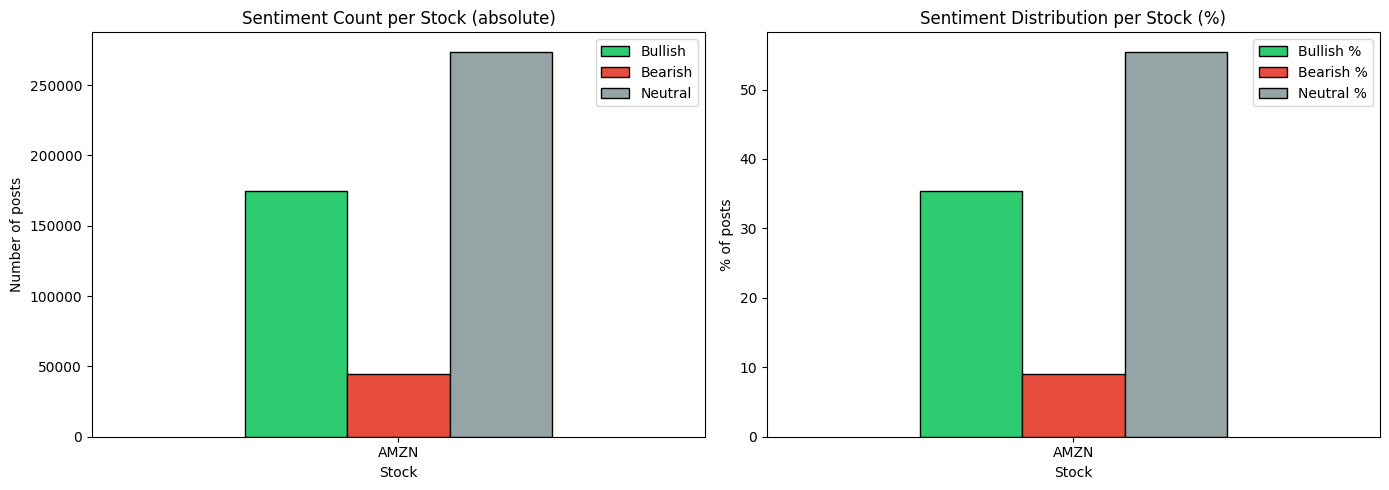

In [1]:
# Bullish / Bearish count per stock
import pandas as pd
import matplotlib.pyplot as plt

sentiment_summary = {}
amazon = "AMZN_cleaned.csv"
dataset_names = ["AMZN"] 
for df, name in zip([pd.read_csv(amazon)], dataset_names):
    counts = df['entities'].value_counts()
    sentiment_summary[name] = {
        'Bullish':  counts.get(1,  0),
        'Bearish':  counts.get(-1, 0),
        'Neutral':  counts.get(0,  0),
        'Total':    len(df),
    }

summary_df = pd.DataFrame(sentiment_summary).T
summary_df['Bullish %'] = (summary_df['Bullish'] / summary_df['Total'] * 100).round(2)
summary_df['Bearish %'] = (summary_df['Bearish'] / summary_df['Total'] * 100).round(2)
summary_df['Neutral %'] = (summary_df['Neutral'] / summary_df['Total'] * 100).round(2)

print("=" * 65)
print("BULLISH / BEARISH COUNT PER STOCK")
print("=" * 65)
print(summary_df[['Bullish', 'Bearish', 'Neutral', 'Total',
                   'Bullish %', 'Bearish %', 'Neutral %']].to_string())

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute counts
summary_df[['Bullish', 'Bearish', 'Neutral']].plot(
    kind='bar', ax=axes[0],
    color=['#2ecc71', '#e74c3c', '#95a5a6'], edgecolor='black'
)
axes[0].set_title('Sentiment Count per Stock (absolute)')
axes[0].set_xlabel('Stock')
axes[0].set_ylabel('Number of posts')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend()

# Percentage
summary_df[['Bullish %', 'Bearish %', 'Neutral %']].plot(
    kind='bar', ax=axes[1],
    color=['#2ecc71', '#e74c3c', '#95a5a6'], edgecolor='black'
)
axes[1].set_title('Sentiment Distribution per Stock (%)')
axes[1].set_xlabel('Stock')
axes[1].set_ylabel('% of posts')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()

plt.tight_layout()
plt.show()

In [20]:
import pandas as pd

stocks = ['AAPL', 'AMZN', 'FB', 'NVDA', 'TSLA']

print(f"{'Stock':<6} {'Combined':>10} {'Final':>10} {'Rows removed':>13}  {'Deduped?':<16} {'Entities clean?'}")
print("-" * 75)

for name in stocks:
    combined = pd.read_csv(f"{name}_combined.csv", usecols=['entities', 'body'])
    final    = pd.read_csv(f"{name}_cleaned.csv",    usecols=['entities', 'body'])

    diff    = len(combined) - len(final)
    deduped = "YES" if diff > 0 else "NO - same size"

    # entities in final should only contain -1, 0, 1
    ent_vals = set(final['entities'].dropna().unique())
    expected = {-1, 0, 1}
    extra    = ent_vals - expected
    entities_ok = "YES" if not extra else f"NO - unexpected: {extra}"

    print(f"{name:<6} {len(combined):>10,} {len(final):>10,} {diff:>13,}  {deduped:<16} {entities_ok}")

Stock    Combined      Final  Rows removed  Deduped?         Entities clean?
---------------------------------------------------------------------------
AAPL      914,962    830,278        84,684  YES              YES
AMZN      539,803    493,518        46,285  YES              YES
FB        359,908    322,735        37,173  YES              YES
NVDA      584,181    529,771        54,410  YES              YES
TSLA    2,204,889  1,953,614       251,275  YES              YES


In [2]:
# this should how many duplicates existed in the cleaned

dataset = "AMZN_cleaned.csv"
df = pd.read_csv(dataset)

duplicates = df.duplicated(subset=['body_clean'], keep=False).sum()
print(f"Total duplicate rows in {dataset}: {duplicates}")



C:\Users\alsom\AppData\Local\Temp\ipykernel_5524\4131765379.py:4: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dataset)


Total duplicate rows in AMZN_cleaned.csv: 0
